In [9]:
import torch
import numpy as np
import torch.nn as nn
from tqdm import trange
from pathlib import Path
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from torchinfo import summary
import time
import sys
import pandas as pd
import scipy
import seaborn as sns
import sklearn.gaussian_process as gp
from scipy import stats


sys.path.append('../..')
import plot_settings
import importlib
#import multi_exp_log
import JH_symbol

from IPython.display import display, Math
from pysr import PySRRegressor, TemplateExpressionSpec
# import mean
from pysr import jl
jl.seval("using Statistics")

colors = plot_settings.colors()

def import_reload():
    plot_settings.apply()
    #importlib.reload(multi_exp_log)
    importlib.reload(JH_symbol)

import_reload()

# Importing data

In [10]:
DT = 1
Q0 = 17921.57581 
#(data['I'][data['trajectory'] == 10].values)[0]  * 3600 / (data['C'][data['trajectory'] == 10].values)[0]  
#print(f'Q0: {Q0:.5f} As')

In [11]:


def read_data(file_name):
    df = pd.read_csv(
        f"../Multi_data/{file_name}.txt",
        sep=';',
        comment="%"
    )
    # cols = u_par,C,t,V,I,F,u,Ue,eta,trajectory,dV,dF,soc
    #df.columns = ['u_par','C','t','V','I','F','u','Ue','eta','trajectory','dV','dF','soc']
    # Sort by time within each batch
    return df


path = f'2_merged_data'

data = read_data(path)
display(data.head())


,u_par,C,t,V,I,F,u,Ue,eta,trajectory,dV,dF,soc
0,0.4,2.2,0.0,4.239833,10.952074,0.030566,-0.057493,4.324996,-0.085164,0,-0.027881,-0.000470,0.999389
1,0.4,2.2,1.0,4.211952,10.952074,0.030096,-0.057493,4.323139,-0.111187,0,-0.016738,-0.000471,0.998778
2,0.4,2.2,2.0,4.195213,10.952074,0.029624,-0.057493,4.321278,-0.126065,0,-0.011734,-0.000471,0.998167
3,0.4,2.2,3.0,4.183479,10.952074,0.029153,-0.057493,4.319417,-0.135938,0,-0.006706,-0.000471,0.997556
4,0.4,2.2,4.0,4.176773,10.952074,0.028682,-0.057493,4.317557,-0.140783,0,-0.005763,-0.000471,0.996944


To deal with more reasonable values, $F$ is measured in GN, while $\Delta u$ is measured in $10^{-5}$ m

## The sampled terrain

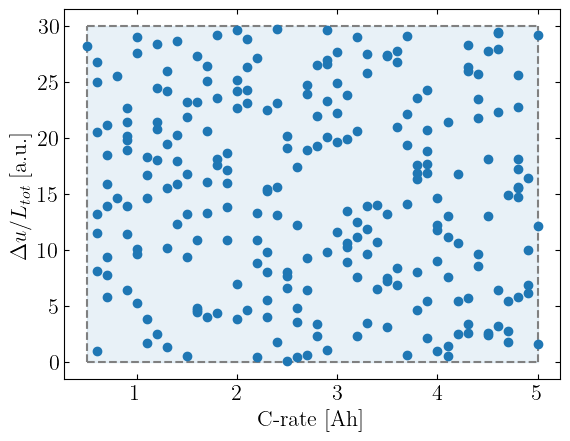

In [12]:
u_C_pairs = data.loc[data['t'] == 0, ['u_par', 'C']]
plt.xlabel('C-rate [Ah]')
plt.ylabel(r'$\Delta u / L_{tot}$ [a.u.]')
plt.vlines(0.5,0,30, color='gray', linestyle='--')
plt.vlines(5,0,30, color='gray', linestyle='--')
plt.hlines(0,0.5,5, color='gray', linestyle='--')
plt.hlines(30,0.5,5, color='gray', linestyle='--')
plt.fill_between([0.5, 5], 0, 30, color='tab:blue', alpha=0.1)
plt.plot(u_C_pairs['C'], u_C_pairs['u_par'], 'o')

# Plotting data

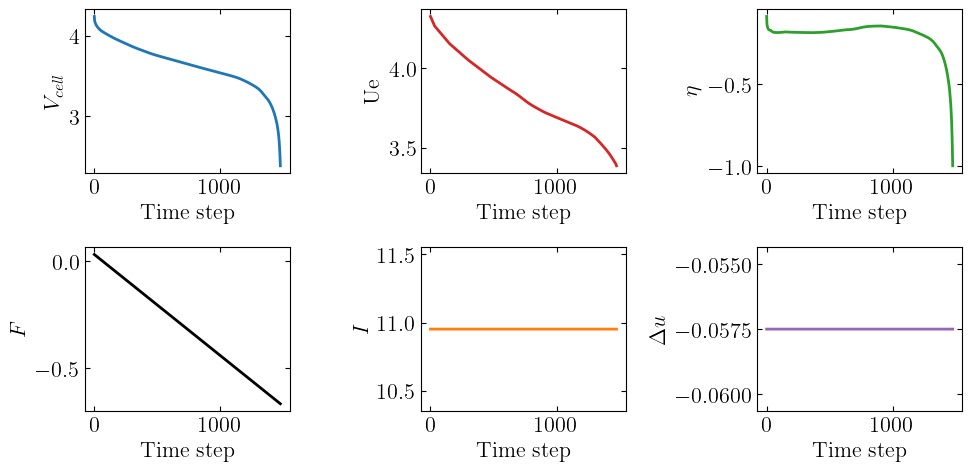

In [13]:

plot_idx = data['trajectory'] == 0
f, ax = plt.subplots(2, 3, figsize=(10, 5))
ax[0,0].plot(data['V'][plot_idx], '-', color = colors[0], lw = 2)
ax[0,0].set_xlabel('Time step')
ax[0,0].set_ylabel('$V_{cell}$')
ax[0,1].plot(data['Ue'][plot_idx], '-', color = colors[1], lw = 2)
ax[0,1].set_xlabel('Time step')
ax[0,1].set_ylabel('Ue')
ax[0,2].plot(data['eta'][plot_idx], '-', color = colors[2], lw = 2)
ax[0,2].set_xlabel('Time step')
ax[0,2].set_ylabel(r'$\eta$')
ax[1,0].plot(data['F'][plot_idx], lw = 2,color = colors[3])
ax[1,0].set_xlabel('Time step')
ax[1,0].set_ylabel(r'$F$')
ax[1,1].plot(data['I'][plot_idx], lw = 2,color = colors[4])
ax[1,1].set_xlabel('Time step')
ax[1,1].set_ylabel(r'$I$')
ax[1,2].plot(data['u'][plot_idx], lw = 2,color = colors[5])
ax[1,2].set_xlabel('Time step')
ax[1,2].set_ylabel(r'$\Delta u$')

plt.tight_layout()
plt.show()

In [14]:
import torch
import torch.nn.functional as TF

def soc_force_func(soc, variable = 'F'):   
    if variable == 'F': 
        forcing_const = 0.995
    elif variable == 'U':
        forcing_const = 0.995
    return 1 - np.exp(-(1-soc) / (1 - forcing_const));

class MyModel(nn.Module):
    def __init__(self, input_size=3, hidden_size=256): 
        super(MyModel, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 2)   # output size is 2 for (V_cell, F)
        )

    def forward(self, x):
        
        if True:
            Fs_raw = self.net(x)[:,0] #* force_func(soc)  # (T,)
            U1_raw = self.net(x)[:,1] 
            soc = x[:,2]
            Fs = soc_force_func(soc, variable='F') * Fs_raw;
            U1 = soc_force_func(soc, variable = 'U') * TF.softplus(U1_raw);
            
            return Fs, U1
        else:
            R0_raw, Fs_raw, U1_raw = self.net(x)[:,0], self.net(x)[:,1], self.net(x)[:,2]
            R0 = R0_raw#torch.clamp(R0_raw, 0, 1) #TF.softplus(R0_raw)  # Ensure R0 is non-negative
            Fs = Fs_raw#force_func(soc) * Fs_raw
            U1 = U1_raw # torch.clamp(U1_raw, 0, 1) #TF.softplus(U1_raw)  # Ensure U1 is non-negative

            return R0, Fs, U1

In [15]:
def load_saved_model(path = 'JH_model_8_N248'):
    m = MyModel()
    m.load_state_dict(torch.load(f'../multi_models/{path}.pth'))
    m.eval()
    return m

N_trajs = len(data['trajectory'].unique())


X = data[['I','u','soc','Ue','trajectory']].values
y = data[['V','F','trajectory']].values


x_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)

split = (data['trajectory']<=int(N_trajs *0.8)).sum()

def _split_flat(arr, split = split):
    return arr[:split], arr[split:]   # Same as reshape(B * T, C)    # (B*T, 4)

x_train, x_test = _split_flat(x_tensor); y_train, y_test = _split_flat(y_tensor)

print(f'Number of trajectories in train: {int(N_trajs * 0.8)} out of {N_trajs}')

print(f'X shape {x_tensor.shape}\ty shape {y_tensor.shape}\nX-train shape: {x_train.shape}\ty-train shape: {y_train.shape}\nX-test shape: {x_test.shape}\ty-test shape: {y_test.shape}')

NN_model = load_saved_model()


Number of trajectories in train: 198 out of 248
X shape torch.Size([415557, 5])	y shape torch.Size([415557, 3])
X-train shape: torch.Size([334590, 5])	y-train shape: torch.Size([334590, 3])
X-test shape: torch.Size([80967, 5])	y-test shape: torch.Size([80967, 3])


In [16]:
print(len(x_train[:,0]))
U1_data = np.zeros((len(x_train[:,0]),6))
    # (N_trajs*0.8, T)
for x_traj in trange(int(N_trajs *0.8)):
    traj_idx = x_train[:,-1] == x_traj
    #print(f'Trajectory {x_traj} has {traj_idx.sum()} time steps')
    # save I,u,soc, and NN_model(X_traj) for each trajectory
    NN_input = x_train[traj_idx,:]
    U1_data[traj_idx,0] =  NN_model(NN_input[:,:3])[1].detach().numpy()  # (T,)
    U1_data[traj_idx,1] =  NN_input[:,0].detach().numpy()  # I
    U1_data[traj_idx,2] =  NN_input[:,1].detach().numpy()  # u
    U1_data[traj_idx,3] =  NN_input[:,2].detach().numpy()  # soc
    U1_data[traj_idx,4] =  np.concat((np.diff(U1_data[traj_idx,0]),[np.diff(U1_data[traj_idx,0])[-1]] ))  # dU1/dt
    U1_data[traj_idx,5] =  x_train[traj_idx,-1].detach().numpy()  # trajectory index

print(U1_data.shape)  # (N_trajs*0.8, T)

df = pd.DataFrame(U1_data, columns=['U1', 'I', 'u', 'soc', 'dU1','trajectory'])
#df.to_csv('multi_models/U1_data.csv', index=False)
df.head()

334590


  0%|          | 0/198 [00:00<?, ?it/s]/var/folders/xl/schcbct544b8f32_b4484x5c0000gn/T/ipykernel_6864/3521825897.py:9: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return 1 - np.exp(-(1-soc) / (1 - forcing_const));
100%|██████████| 198/198 [00:02<00:00, 92.54it/s] 

(334590, 6)


,U1,I,u,soc,dU1,trajectory
0,0.011041,10.952074,-0.057493,0.999389,0.009767,0.0
1,0.020808,10.952074,-0.057493,0.998778,0.008641,0.0
2,0.029449,10.952074,-0.057493,0.998167,0.007644,0.0
3,0.037092,10.952074,-0.057493,0.997556,0.006761,0.0
4,0.043853,10.952074,-0.057493,0.996944,0.005980,0.0


In [ ]:
def get_XY(d_frame):
    for i in range(1,10):
        inds = np.arange(0,len(d_frame)) % i == 0
        if inds.sum() < 5e4:
            break

    X = d_frame[['dU1', 'I', 'u', 'soc']].values
    Y = d_frame['U1'].values
    print(f'Using every {i}th data point for symbolic regression, total points: {inds.sum()}')
    
    return X[inds], Y[inds]

In [ ]:
#f = 0.010424972; 

#g = [(-10870.941 / x1) / cube(cube(x3)), ]

# ECM equation

I want to solve $$V_{B} = U_{eq} - iR_0-U_1,\quad\mathrm{where}\quad \frac{dU_1}{dt} = \frac{U_1}{R_1C_1} - \frac{i}{C_1}. $$

## $\mathrm{SoC}>0.95$

In [ ]:
df_high_soc = df[df['soc'] >= 0.95]

X_data, Y_data = get_XY(df_high_soc)
print(f'X_data shape: {X_data.shape}')
print(f'Y_data shape: {Y_data.shape}')

Using every 1th data point for symbolic regression, total points: 18055
X_data shape: (18055, 4)
Y_data shape: (18055,)


In [ ]:
import_reload()
model_high = JH_symbol.run_symbolic_regression(X_data, Y_data, model = None,run_id = 'high_soc')

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Text(0.5, 1.0, 'Model Complexity vs Loss')

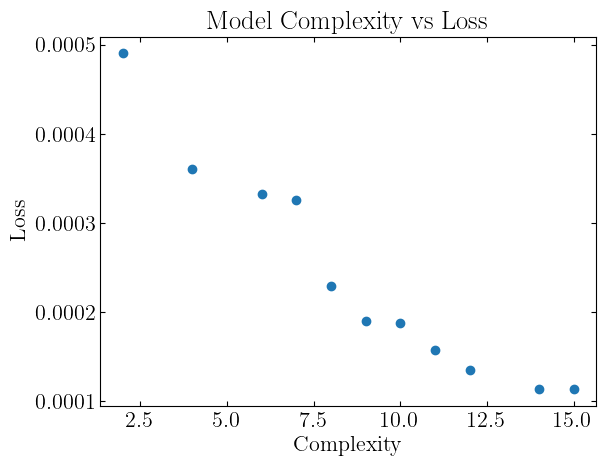

In [ ]:
df_model_high = model_high.equations_
plt.scatter(df_model_high['complexity'], df_model_high['loss'])
plt.xlabel('Complexity')
plt.ylabel('Loss')
plt.title('Model Complexity vs Loss')

In [ ]:

print(df_model_high['equation'][df_model_high['loss'] == df_model_high['loss'].min()].values[0])

R = sqrt(#1 / exp(#1)) + square(0.9611573 / #3); C = square(log(#1 / 63.645195))


In [ ]:
for i in range(len(df_model_high)):
    print(f"Model {i}: Complexity={df_model_high['complexity'][i]}, Loss={df_model_high['loss'][i]}")
    print(f"Equation: {df_model_high['equation'][i]}\n")

Model 0: Complexity=2, Loss=0.00049006153
Equation: R = 0.9876979; C = 1.215465

Model 1: Complexity=4, Loss=0.00036027323
Equation: R = -0.9970977; C = -27.59187 / #1

Model 2: Complexity=6, Loss=0.00033215186
Equation: R = 0.9990739; C = square(log(#1 / 64.11173))

Model 3: Complexity=7, Loss=0.0003254468
Equation: R = exp(0.3149334 / #1); C = -28.124544 / #1

Model 4: Complexity=8, Loss=0.00022958947
Equation: R = exp(square(1.6182523 / #1)); C = -28.096416 / #1

Model 5: Complexity=9, Loss=0.00019028064
Equation: R = exp(sqrt(2.1505682 / exp(#1))); C = 27.942694 / #1

Model 6: Complexity=10, Loss=0.00018785393
Equation: R = (1.0293 / #1) + 0.92333376; C = square(log(63.645195 / #1))

Model 7: Complexity=11, Loss=0.0001577413
Equation: R = exp(sqrt(2.1809092 / exp(#1))); C = square(log(#1 / 64.297325))

Model 8: Complexity=12, Loss=0.00013455625
Equation: R = (square(#1) / exp(#1)) + 0.98236823; C = square(log(63.653854 / #1))

Model 9: Complexity=14, Loss=0.00011389385
Equation: R 

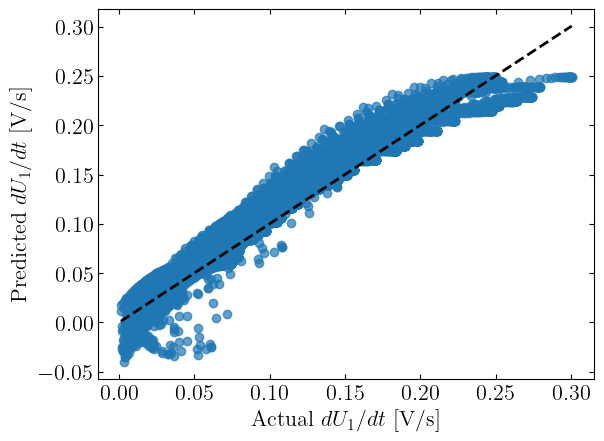

In [ ]:
# Parity plot
Y_pred = model_high.predict(X_data)
plt.scatter(Y_data, Y_pred, color=colors[0],alpha = 0.7)
plt.plot([Y_data.min(), Y_data.max()], [Y_data.min(), Y_data.max()], 'k--', lw=2)
plt.xlabel('Actual $dU_1/dt$ [V/s]')
plt.ylabel('Predicted $dU_1/dt$ [V/s]')
plt.show()

Using every 1th data point for symbolic regression, total points: 18055
Using equation: R = exp(sqrt(2.1505682 / exp(#1))); C = 27.942694 / #1 for parity plot
complexity: 9, loss: 0.00019028064


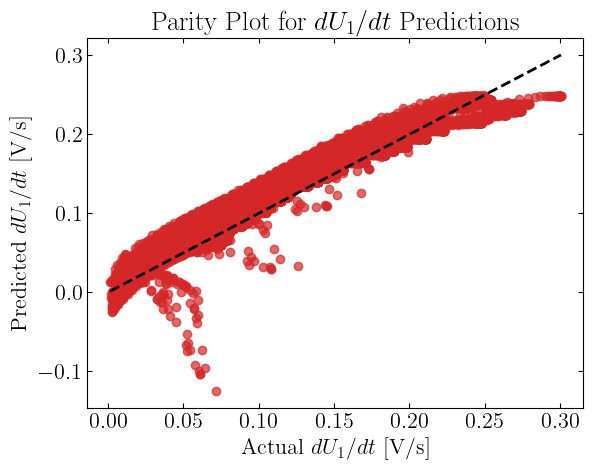

In [ ]:
model_nr = 5
X_data, Y_data = get_XY(df_high_soc)
y_pred = model_high.equations_.iloc[model_nr]["lambda_format"](X_data)
print(f'Using equation: {model_high.equations_.iloc[model_nr]["equation"]} for parity plot')
print(f'complexity: {model_high.equations_.iloc[model_nr]["complexity"]}, loss: {model_high.equations_.iloc[model_nr]["loss"]}')
plt.scatter(Y_data, y_pred, color=colors[1],alpha = 0.7)
plt.plot([Y_data.min(), Y_data.max()], [Y_data.min(), Y_data.max()], 'k--', lw=2)
plt.xlabel('Actual $dU_1/dt$ [V/s]')
plt.ylabel('Predicted $dU_1/dt$ [V/s]')
plt.title('Parity Plot for $dU_1/dt$ Predictions')
plt.show()

In [ ]:
# get best model and print equation and loss
best = model_high.get_best()
print("Best equation:\n",best["equation"])
print("Loss:", best["loss"])
print("Best model complexity:", best["complexity"])

Best equation:
 R = exp(sqrt(2.1809092 / exp(#1))); C = square(log(#1 / 64.297325))
Loss: 0.0001577413
Best model complexity: 11


## $\mathrm{SOC}<0.20$

In [ ]:
df_low_soc = df[df['soc'] < 0.3]

X_data, Y_data = get_XY(df_low_soc)
print(f'X_data shape: {X_data.shape}')
print(f'Y_data shape: {Y_data.shape}')

Using every 2th data point for symbolic regression, total points: 40015
X_data shape: (40015, 4)
Y_data shape: (40015,)


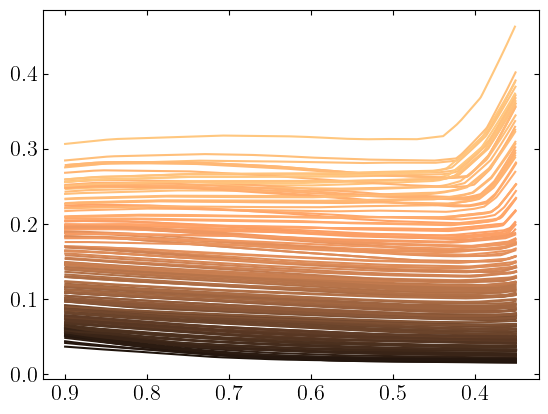

In [ ]:
cmap = plt.get_cmap('copper')

for i in df['trajectory'].unique():
    color = cmap(df['I'][(df['soc'] > 0.35) & (df['soc'] < 0.9) &(df['trajectory'] == i)].mean() / df['I'].max())  # Normalize I for color mapping
    if i < 10:
        pass
    else:
        plt.plot(df['soc'][(df['soc'] > 0.35) & (df['soc'] < 0.9) &(df['trajectory'] == i)], df['U1'][(df['soc'] > 0.35) & (df['soc'] < 0.9) &(df['trajectory'] == i)], color = color)
#plt.plot(X_data[:,3], Y_data, 'o', color=colors[2], alpha=0.5)
plt.gca().invert_xaxis()

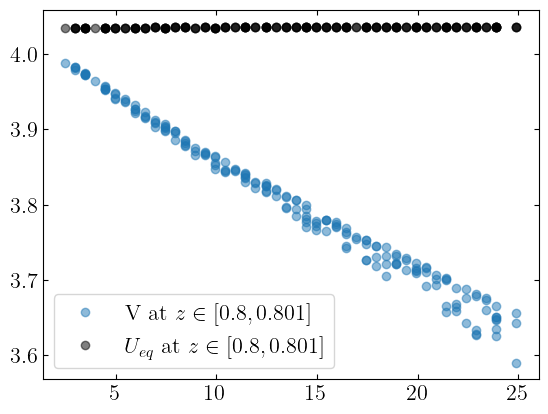

In [42]:
z_low = 0.8
z_high = z_low + 0.001

for i in df['trajectory'].unique():
    if i < 10:
        pass
    else:
        plt.plot(data['I'][(data['soc'] > z_low)&(data['soc'] < z_high)&(data['trajectory'] == i)].mean(), data['V'][(data['soc'] > z_low)&(data['soc'] < z_high)&(data['trajectory'] == i)].mean(),  'o', color=colors[0], alpha=0.5)
        plt.plot(data['I'][(data['soc'] > z_low)&(data['soc'] < z_high)&(data['trajectory'] == i)].mean(), data['Ue'][(data['soc'] > z_low)&(data['soc'] < z_high)&(data['trajectory'] == i)].mean(), 'o', color=colors[3], alpha=0.5)
plt.legend([rf'V at $z\in[{z_low},{z_high}]$', rf'$U_{{eq}}$ at $z\in[{z_low},{z_high}]$'])

In [22]:
import_reload()
model_low = JH_symbol.run_symbolic_regression(X_data, Y_data, model = None, run_id = 'low_soc')

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Text(0.5, 1.0, 'Model Complexity vs Loss')

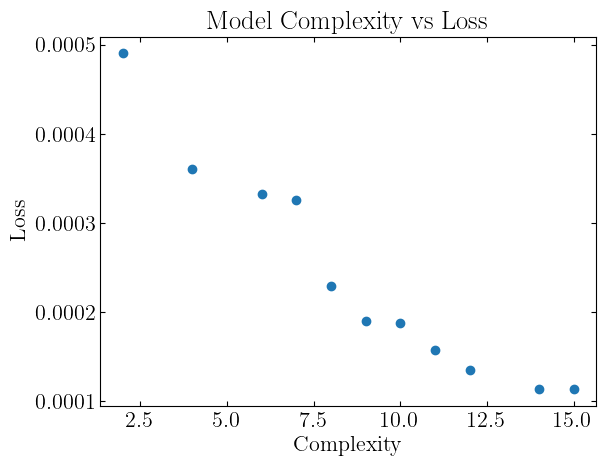

In [23]:
df_model_low = model_high.equations_
plt.scatter(df_model_low['complexity'], df_model_low['loss'])
plt.xlabel('Complexity')
plt.ylabel('Loss')
plt.title('Model Complexity vs Loss')

In [24]:
for i in range(len(df_model_low)):
    print(f"Model {i}: Complexity={df_model_low['complexity'][i]}, Loss={df_model_low['loss'][i]}")
    print(f"Equation: {df_model_low['equation'][i]}\n")

Model 0: Complexity=2, Loss=0.00049006153
Equation: R = 0.9876979; C = 1.215465

Model 1: Complexity=4, Loss=0.00036027323
Equation: R = -0.9970977; C = -27.59187 / #1

Model 2: Complexity=6, Loss=0.00033215186
Equation: R = 0.9990739; C = square(log(#1 / 64.11173))

Model 3: Complexity=7, Loss=0.0003254468
Equation: R = exp(0.3149334 / #1); C = -28.124544 / #1

Model 4: Complexity=8, Loss=0.00022958947
Equation: R = exp(square(1.6182523 / #1)); C = -28.096416 / #1

Model 5: Complexity=9, Loss=0.00019028064
Equation: R = exp(sqrt(2.1505682 / exp(#1))); C = 27.942694 / #1

Model 6: Complexity=10, Loss=0.00018785393
Equation: R = (1.0293 / #1) + 0.92333376; C = square(log(63.645195 / #1))

Model 7: Complexity=11, Loss=0.0001577413
Equation: R = exp(sqrt(2.1809092 / exp(#1))); C = square(log(#1 / 64.297325))

Model 8: Complexity=12, Loss=0.00013455625
Equation: R = (square(#1) / exp(#1)) + 0.98236823; C = square(log(63.653854 / #1))

Model 9: Complexity=14, Loss=0.00011389385
Equation: R 

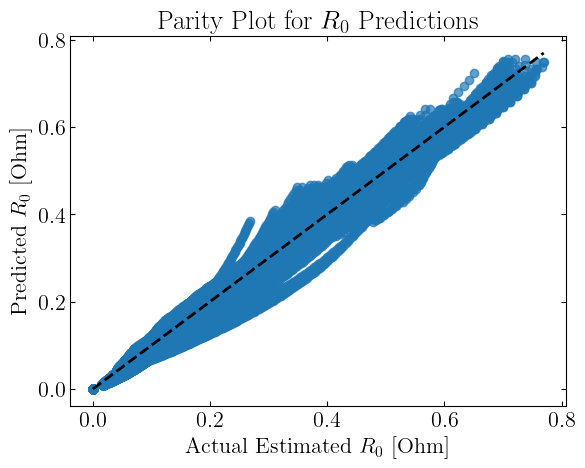

In [25]:
Y_pred = model_low.predict(X_data)
plt.scatter(Y_data, Y_pred, color=colors[0],alpha = 0.7)
plt.plot([Y_data.min(), Y_data.max()], [Y_data.min(), Y_data.max()], 'k--', lw=2)
plt.xlabel('Actual Estimated $R_0$ [Ohm]')
plt.ylabel('Predicted $R_0$ [Ohm]')
plt.title('Parity Plot for $R_0$ Predictions')
plt.show()

Using every 2th data point for symbolic regression, total points: 40015
Using equation: R = (#1 / (#3 + -0.0140116345)) * 0.019332306; C = -4.5055957 for parity plot
complexity: 8, loss: 0.0036672626


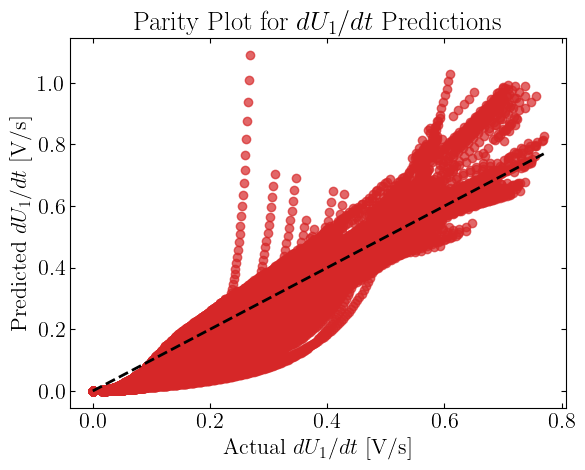

In [26]:
X_data, Y_data = get_XY(df_low_soc)
y_pred = model_low.equations_.iloc[5]["lambda_format"](X_data)
print(f'Using equation: {model_low.equations_.iloc[5]["equation"]} for parity plot')
print(f'complexity: {model_low.equations_.iloc[5]["complexity"]}, loss: {model_low.equations_.iloc[5]["loss"]}')
plt.scatter(Y_data, y_pred, color=colors[1],alpha = 0.7)
plt.plot([Y_data.min(), Y_data.max()], [Y_data.min(), Y_data.max()], 'k--', lw=2)
plt.xlabel('Actual $dU_1/dt$ [V/s]')
plt.ylabel('Predicted $dU_1/dt$ [V/s]')
plt.title('Parity Plot for $dU_1/dt$ Predictions')
plt.show()

Using every 1th data point for symbolic regression, total points: 1046


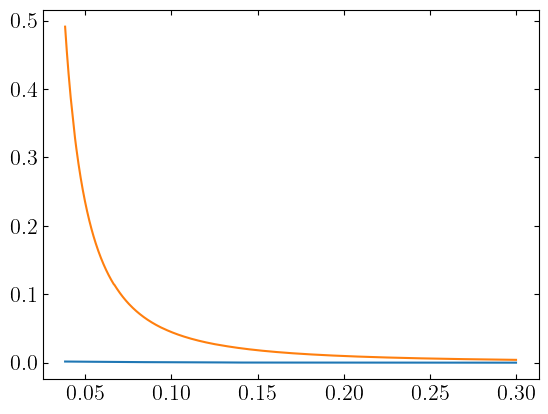

In [27]:
plt.plot(df_low_soc[df_low_soc['trajectory'] == 3]['soc'],df_low_soc[df_low_soc['trajectory'] == 3]['dU1'], label='dU1/dt')
plt.plot(df_low_soc[df_low_soc['trajectory'] == 3]['soc'],model_low.equations_.iloc[5]["lambda_format"](get_XY(df_low_soc[df_low_soc['trajectory'] == 3])[0]), label='U1')

In [28]:
best = model_high.get_best()
print("Best equation:\n",best["equation"])
print("Loss:", best["loss"])

Best equation:
 R = exp(sqrt(2.1809092 / exp(#1))); C = square(log(#1 / 64.297325))
Loss: 0.0001577413


## $0.20<\mathrm{SOC}<0.95$

In [29]:
df_mid_soc = df[df['soc'] < 0.20]

X_data, Y_data = get_XY(df_mid_soc)
print(f'X_data shape: {X_data.shape}')
print(f'Y_data shape: {Y_data.shape}')

Using every 1th data point for symbolic regression, total points: 43943
X_data shape: (43943, 4)
Y_data shape: (43943,)


In [30]:
import_reload()
model_mid = JH_symbol.run_symbolic_regression(X_data, Y_data, model = None, run_id = 'mid_soc')

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Text(0.5, 1.0, 'Model Complexity vs Loss')

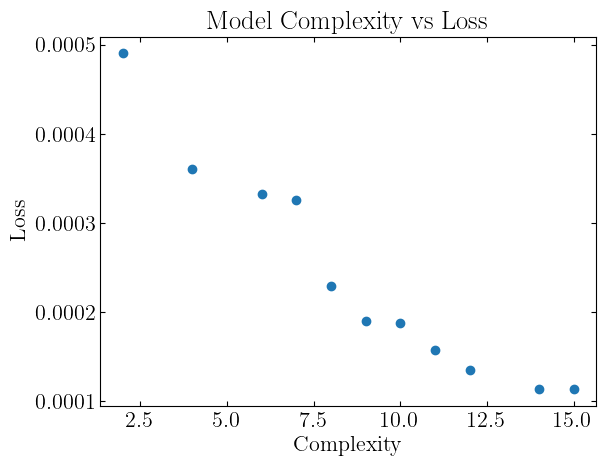

In [31]:
df_model_mid = model_high.equations_
plt.scatter(df_model_mid['complexity'], df_model_mid['loss'])
plt.xlabel('Complexity')
plt.ylabel('Loss')
plt.title('Model Complexity vs Loss')

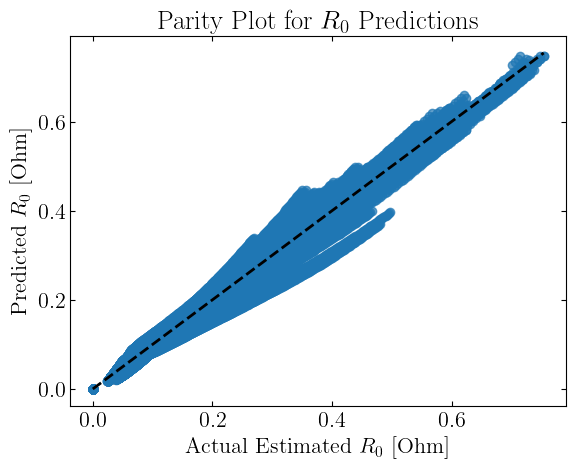

In [32]:
Y_pred = model_mid.predict(X_data)
plt.scatter(Y_data, Y_pred, color=colors[0],alpha = 0.7)
plt.plot([Y_data.min(), Y_data.max()], [Y_data.min(), Y_data.max()], 'k--', lw=2)
plt.xlabel('Actual Estimated $R_0$ [Ohm]')
plt.ylabel('Predicted $R_0$ [Ohm]')
plt.title('Parity Plot for $R_0$ Predictions')
plt.show()

Using every 1th data point for symbolic regression, total points: 43943
Using equation: R = (-0.15131481 / (#3 + 0.027244499)) + -0.7832478; C = 1.8351634e-9 for parity plot
complexity: 8, loss: 0.003044501


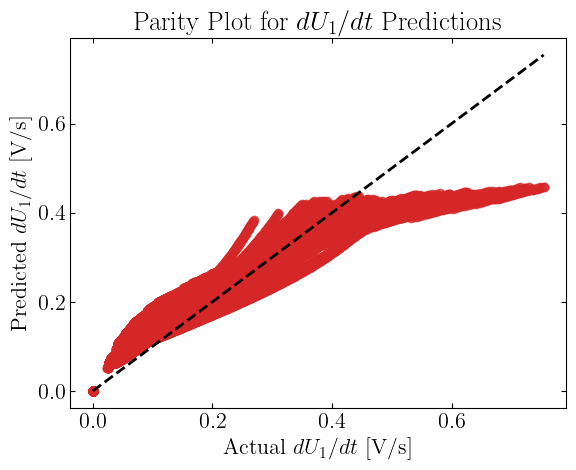

In [33]:
model_nr = 5
X_data, Y_data = get_XY(df_mid_soc)
y_pred = model_mid.equations_.iloc[model_nr]["lambda_format"](X_data)
print(f'Using equation: {model_mid.equations_.iloc[model_nr]["equation"]} for parity plot')
print(f'complexity: {model_mid.equations_.iloc[model_nr]["complexity"]}, loss: {model_mid.equations_.iloc[model_nr]["loss"]}')
plt.scatter(Y_data, y_pred, color=colors[1],alpha = 0.7)
plt.plot([Y_data.min(), Y_data.max()], [Y_data.min(), Y_data.max()], 'k--', lw=2)
plt.xlabel('Actual $dU_1/dt$ [V/s]')
plt.ylabel('Predicted $dU_1/dt$ [V/s]')
plt.title('Parity Plot for $dU_1/dt$ Predictions')
plt.show()

In [34]:
for i in range(len(df_model_mid)):
    print(f"Model {i}: Complexity={df_model_mid['complexity'][i]}, Loss={df_model_low['loss'][i]}")
    print(f"Equation: {df_model_mid['equation'][i]}\n")

Model 0: Complexity=2, Loss=0.00049006153
Equation: R = 0.9876979; C = 1.215465

Model 1: Complexity=4, Loss=0.00036027323
Equation: R = -0.9970977; C = -27.59187 / #1

Model 2: Complexity=6, Loss=0.00033215186
Equation: R = 0.9990739; C = square(log(#1 / 64.11173))

Model 3: Complexity=7, Loss=0.0003254468
Equation: R = exp(0.3149334 / #1); C = -28.124544 / #1

Model 4: Complexity=8, Loss=0.00022958947
Equation: R = exp(square(1.6182523 / #1)); C = -28.096416 / #1

Model 5: Complexity=9, Loss=0.00019028064
Equation: R = exp(sqrt(2.1505682 / exp(#1))); C = 27.942694 / #1

Model 6: Complexity=10, Loss=0.00018785393
Equation: R = (1.0293 / #1) + 0.92333376; C = square(log(63.645195 / #1))

Model 7: Complexity=11, Loss=0.0001577413
Equation: R = exp(sqrt(2.1809092 / exp(#1))); C = square(log(#1 / 64.297325))

Model 8: Complexity=12, Loss=0.00013455625
Equation: R = (square(#1) / exp(#1)) + 0.98236823; C = square(log(63.653854 / #1))

Model 9: Complexity=14, Loss=0.00011389385
Equation: R 

In [35]:
best = model_mid.get_best()
print("Best equation:\n",best["equation"])
print("Loss:", best["loss"])

Best equation:
 R = square((0.27804828 / (#3 + 0.12845047)) + (#1 * 0.023848474)); C = 4.2668904e-9
Loss: 0.0003206063


In [36]:
df_model_high.to_csv('model_high.csv', index=False)
df_model_mid.to_csv('model_mid.csv', index=False)
df_model_low.to_csv('model_low.csv', index=False)